# House Price Prediction using Linear Regression

## 1. Introduction

This notebook implements **Linear Regression** to predict house prices using the Ames Housing Dataset from Kaggle. The goal is to predict the final sale price (`SalePrice`) of residential homes in Ames, Iowa, based on 79 explanatory features describing various aspects of the properties.

### Dataset Source
- **Kaggle Competition**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)
- **Original Source**: Dean De Cock, Ames Housing Dataset
- **Training samples**: 1,460 | **Test samples**: 1,459 | **Features**: 79



## 2. Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Feature selection
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# Scipy for statistical tests
from scipy import stats
from scipy.stats import norm, skew, kurtosis

# Set display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!


## 3. Data Loading and Initial Exploration

In [2]:
# Load datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Store test IDs for submission
test_ids = test_df['Id']

print(f'Training set: {train_df.shape[0]} samples, {train_df.shape[1]} features')
print(f'Test set:     {test_df.shape[0]} samples, {test_df.shape[1]} features')
print(f'\nTarget variable: SalePrice')
print(f'Number of features: {train_df.shape[1] - 2} (excluding Id and SalePrice)')

Training set: 1460 samples, 81 features
Test set:     1459 samples, 80 features

Target variable: SalePrice
Number of features: 79 (excluding Id and SalePrice)


In [3]:
# Display first few rows
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Statistical summary of numerical features
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
# Data types distribution
print('Data Types Distribution:')
print(train_df.dtypes.value_counts())
print(f'\nNumerical features: {train_df.select_dtypes(include=[np.number]).shape[1]}')
print(f'Categorical features: {train_df.select_dtypes(exclude=[np.number]).shape[1]}')

Data Types Distribution:
object     43
int64      35
float64     3
Name: count, dtype: int64

Numerical features: 38
Categorical features: 43


## 4. Exploratory Data Analysis (EDA)

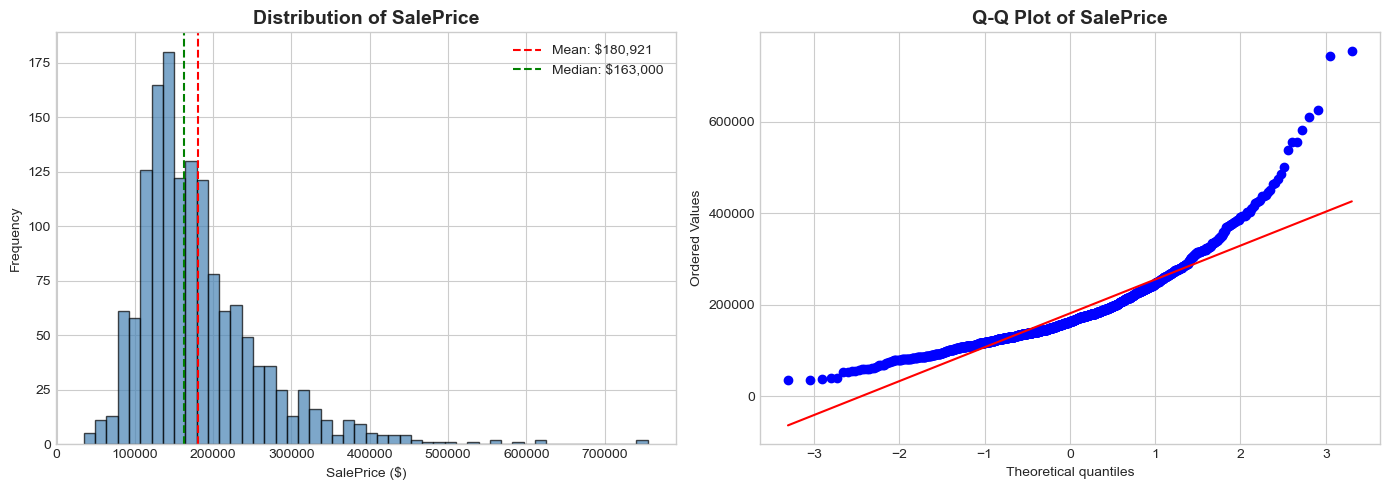

Skewness: 1.8829
Kurtosis: 6.5363

Note: SalePrice is right-skewed. Log transformation will be applied.


In [6]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_df['SalePrice'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of SalePrice', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['SalePrice'].mean(), color='red', linestyle='--', label=f"Mean: ${train_df['SalePrice'].mean():,.0f}")
axes[0].axvline(train_df['SalePrice'].median(), color='green', linestyle='--', label=f"Median: ${train_df['SalePrice'].median():,.0f}")
axes[0].legend()

# Q-Q Plot
stats.probplot(train_df['SalePrice'], plot=axes[1])
axes[1].set_title('Q-Q Plot of SalePrice', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Skewness: {train_df["SalePrice"].skew():.4f}')
print(f'Kurtosis: {train_df["SalePrice"].kurtosis():.4f}')
print('\nNote: SalePrice is right-skewed. Log transformation will be applied.')

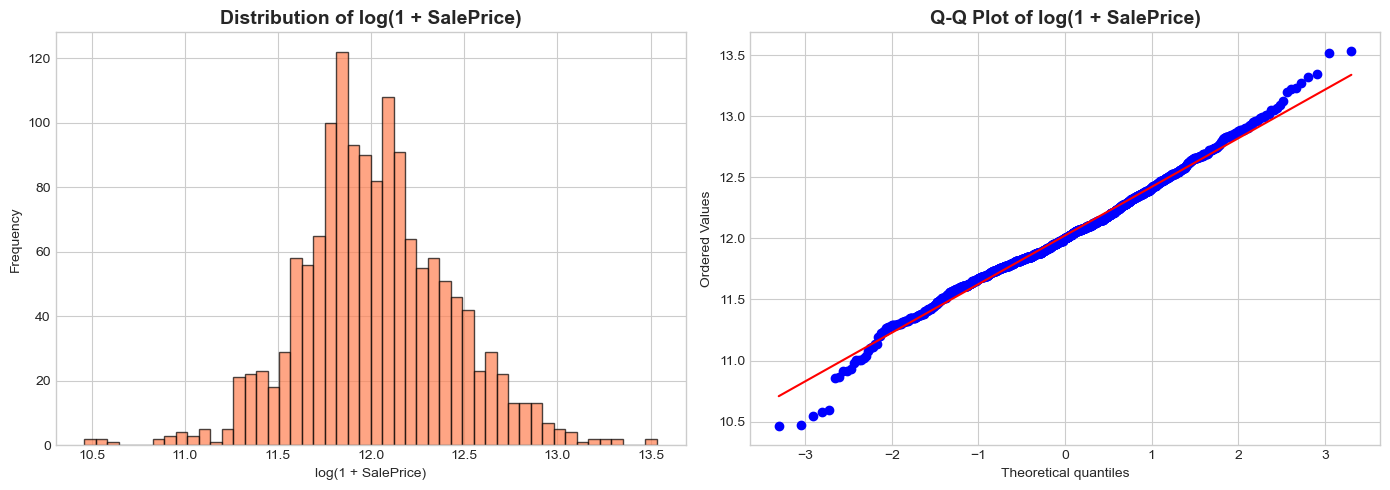

Skewness after log transform: 0.1213
Kurtosis after log transform: 0.8095
The log-transformed target is much closer to a normal distribution.


In [7]:
# Log-transformed SalePrice distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_price = np.log1p(train_df['SalePrice'])

axes[0].hist(log_price, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of log(1 + SalePrice)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('log(1 + SalePrice)')
axes[0].set_ylabel('Frequency')

stats.probplot(log_price, plot=axes[1])
axes[1].set_title('Q-Q Plot of log(1 + SalePrice)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Skewness after log transform: {log_price.skew():.4f}')
print(f'Kurtosis after log transform: {log_price.kurtosis():.4f}')
print('The log-transformed target is much closer to a normal distribution.')

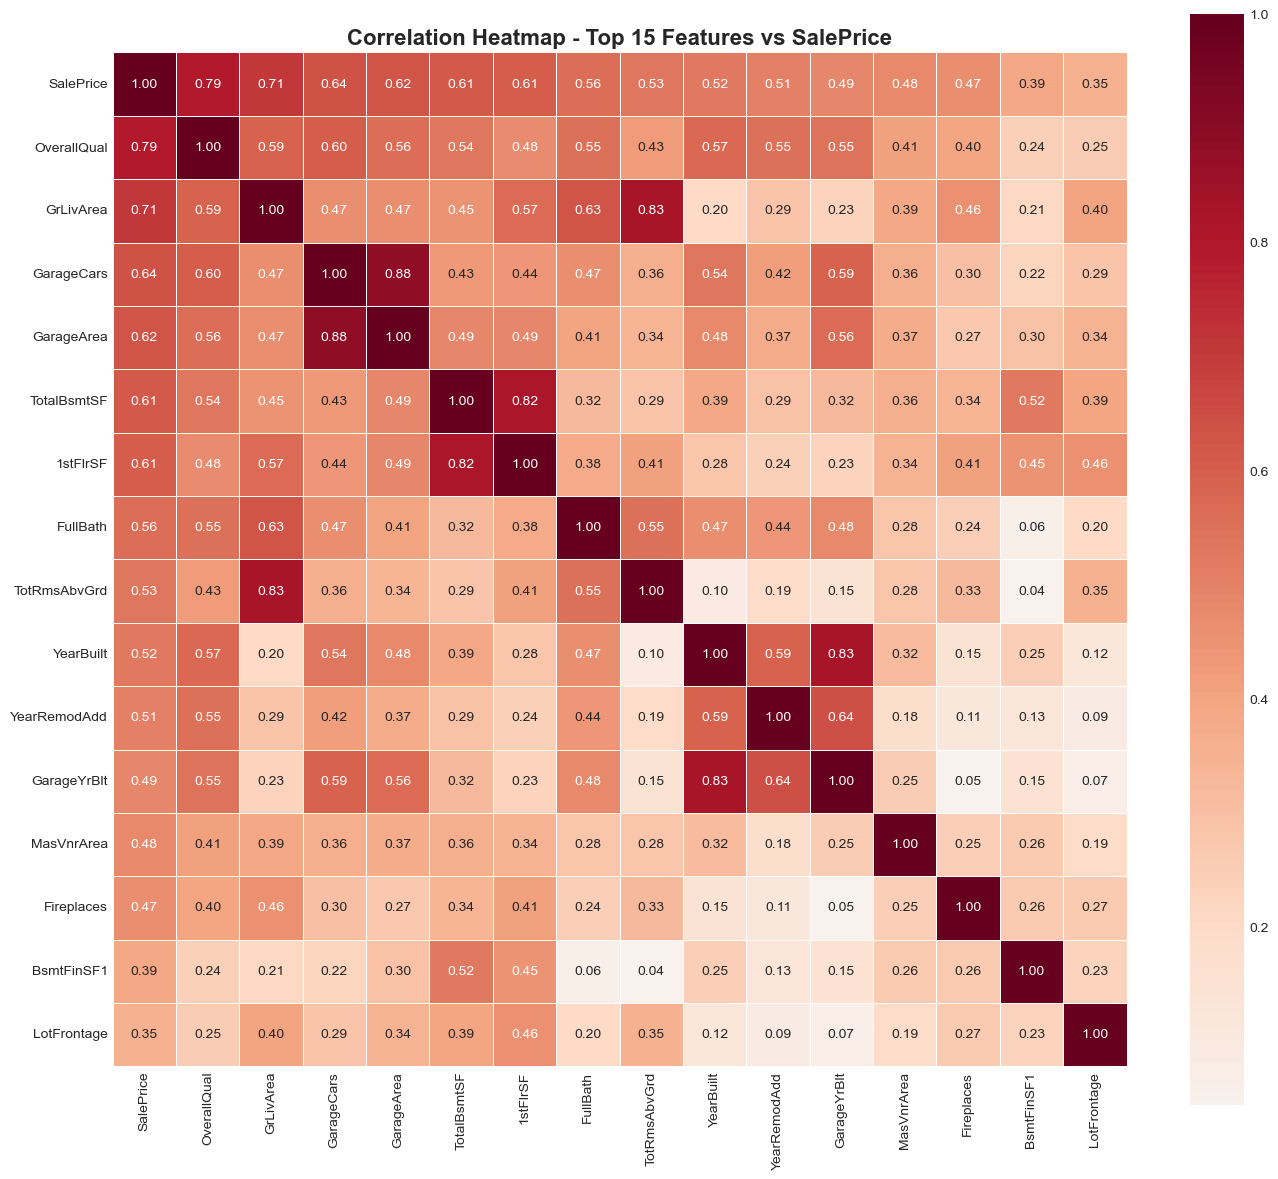

In [8]:
# Correlation heatmap - Top 15 features correlated with SalePrice
numeric_df = train_df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
top_corr_features = correlation_matrix['SalePrice'].abs().sort_values(ascending=False).head(16).index

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(numeric_df[top_corr_features].corr(), annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap - Top 15 Features vs SalePrice', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

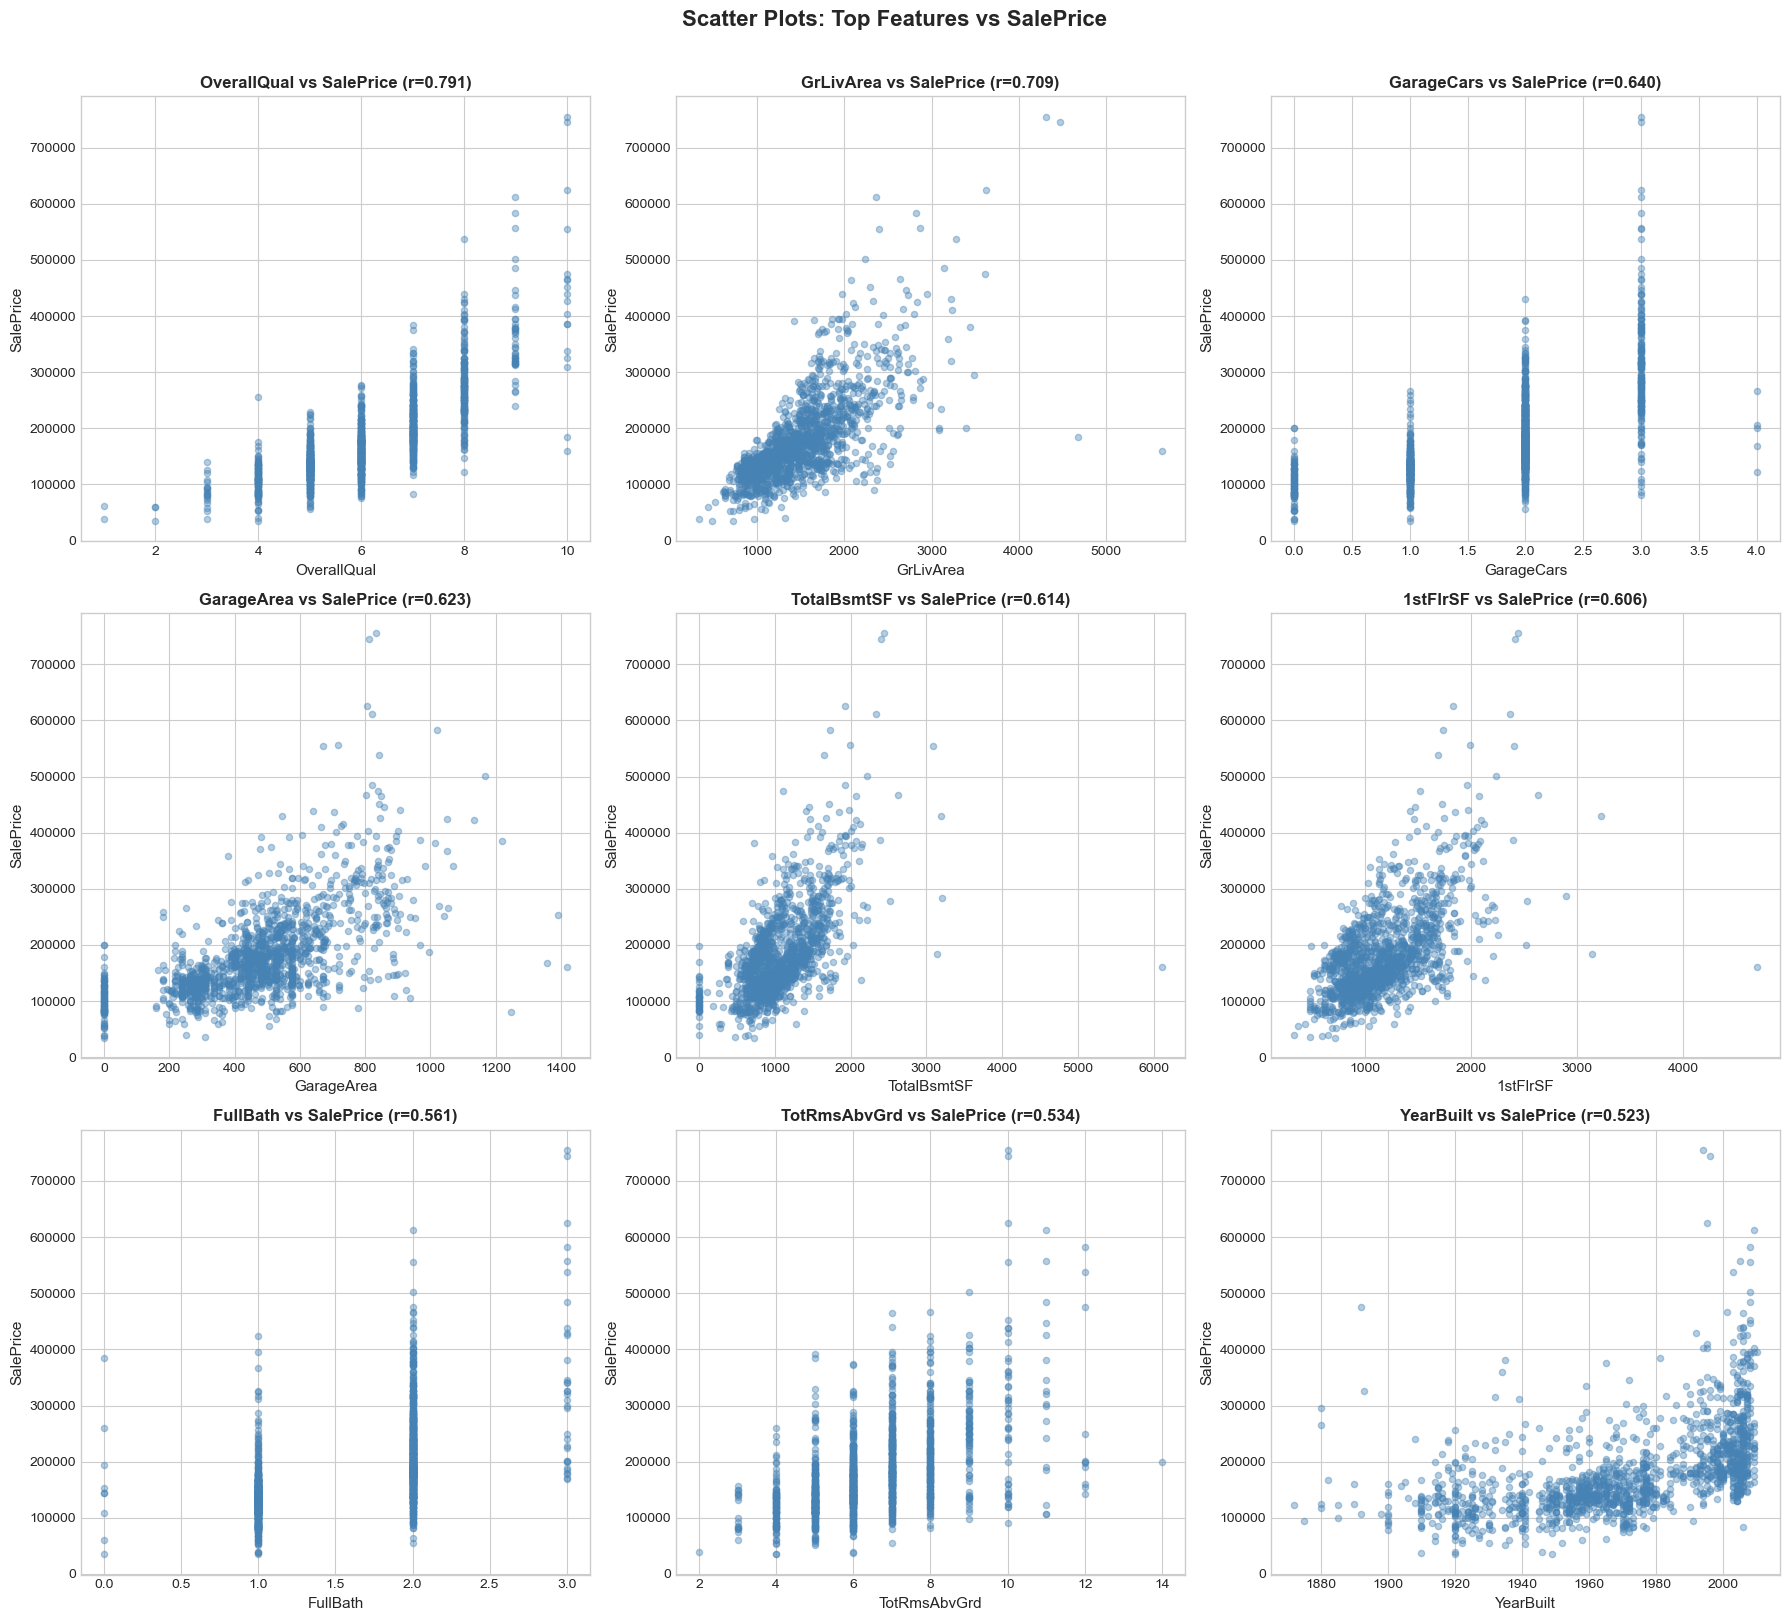

In [9]:
# Scatter plots of top correlated features with SalePrice
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 
                'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt']

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for idx, feat in enumerate(top_features):
    row, col = idx // 3, idx % 3
    axes[row, col].scatter(train_df[feat], train_df['SalePrice'], alpha=0.4, s=20, color='steelblue')
    axes[row, col].set_xlabel(feat, fontsize=11)
    axes[row, col].set_ylabel('SalePrice', fontsize=11)
    corr = train_df[feat].corr(train_df['SalePrice'])
    axes[row, col].set_title(f'{feat} vs SalePrice (r={corr:.3f})', fontsize=12, fontweight='bold')

plt.suptitle('Scatter Plots: Top Features vs SalePrice', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

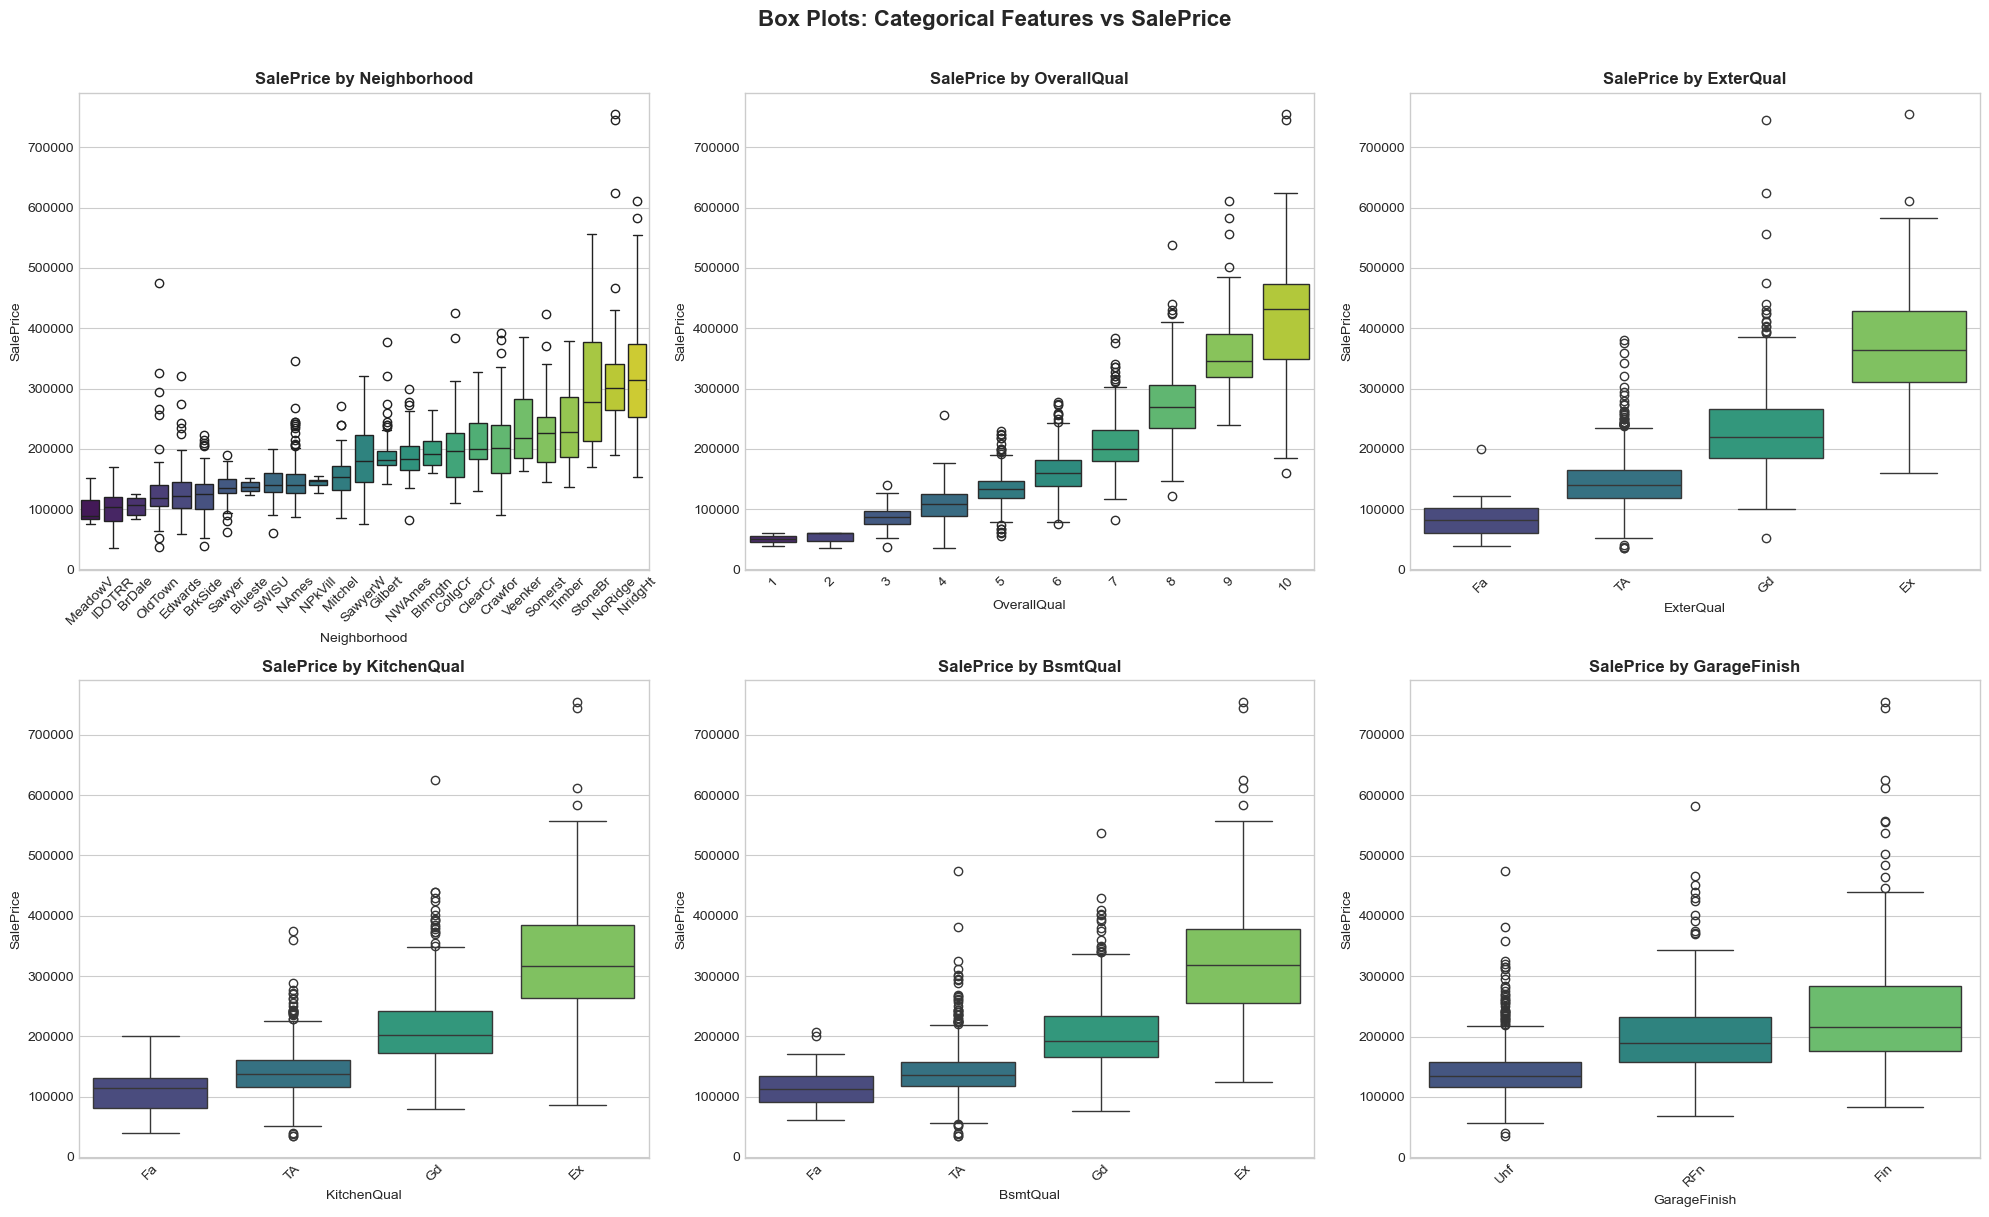

In [10]:
# Box plots for key categorical features
cat_features = ['Neighborhood', 'OverallQual', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for idx, feat in enumerate(cat_features):
    row, col = idx // 3, idx % 3
    data = train_df[[feat, 'SalePrice']].dropna()
    order = data.groupby(feat)['SalePrice'].median().sort_values().index
    sns.boxplot(x=feat, y='SalePrice', data=data, order=order, ax=axes[row, col], palette='viridis')
    axes[row, col].set_title(f'SalePrice by {feat}', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.suptitle('Box Plots: Categorical Features vs SalePrice', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

### 5.1 Missing Value Analysis and Treatment

In [11]:
# Combine train and test for consistent preprocessing
y_train = np.log1p(train_df['SalePrice'])  # Log transform target
all_data = pd.concat([train_df.drop('SalePrice', axis=1), test_df], axis=0).reset_index(drop=True)
all_data.drop('Id', axis=1, inplace=True)

print(f'Combined dataset: {all_data.shape}')

# Analyze missing values
missing = all_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(all_data)) * 100

missing_info = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(f'\nFeatures with missing values: {len(missing_info)}')
print(missing_info)

Combined dataset: (2919, 79)

Features with missing values: 34
              Missing Count  Missing %
PoolQC                 2909  99.657417
MiscFeature            2814  96.402878
Alley                  2721  93.216855
Fence                  2348  80.438506
MasVnrType             1766  60.500171
FireplaceQu            1420  48.646797
LotFrontage             486  16.649538
GarageFinish            159   5.447071
GarageQual              159   5.447071
GarageCond              159   5.447071
GarageYrBlt             159   5.447071
GarageType              157   5.378554
BsmtExposure             82   2.809181
BsmtCond                 82   2.809181
BsmtQual                 81   2.774923
BsmtFinType2             80   2.740665
BsmtFinType1             79   2.706406
MasVnrArea               23   0.787941
MSZoning                  4   0.137033
BsmtFullBath              2   0.068517
BsmtHalfBath              2   0.068517
Functional                2   0.068517
Utilities                 2   0.068517
G

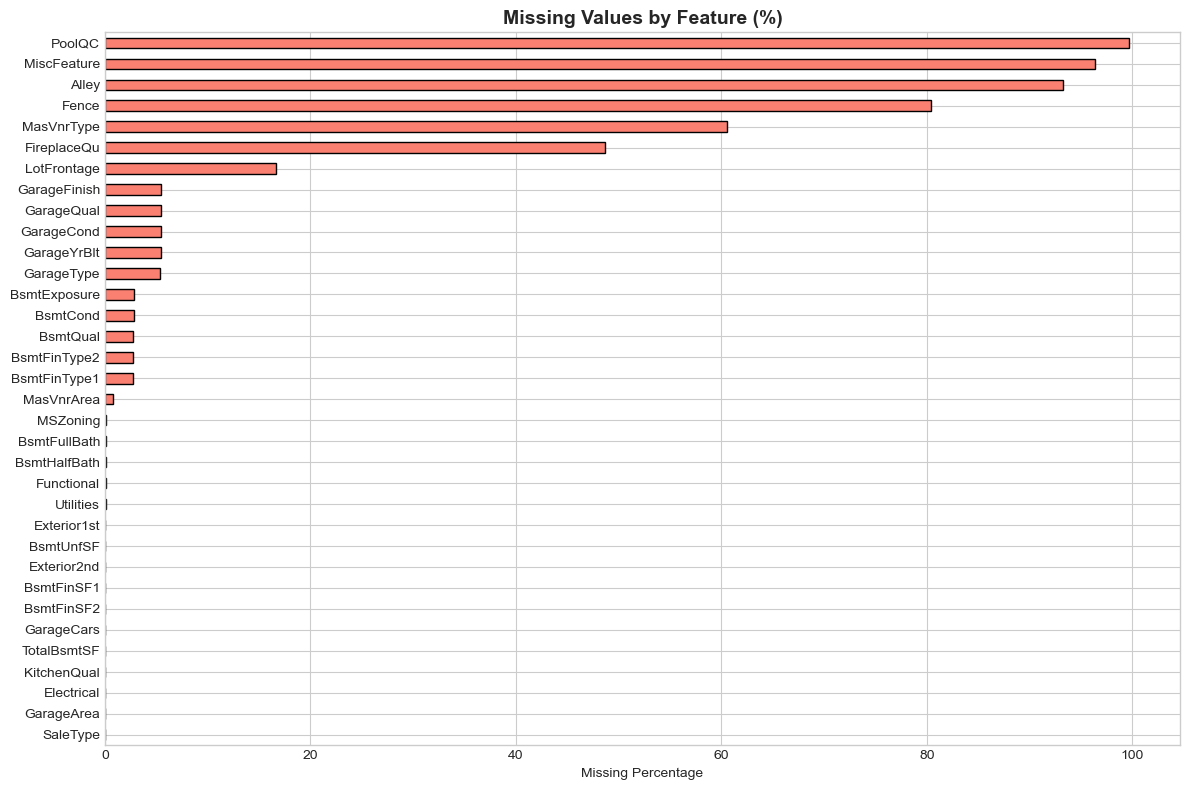

In [12]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 8))
missing_pct_sorted = missing_pct.sort_values(ascending=True)
missing_pct_sorted.plot(kind='barh', color='salmon', edgecolor='black', ax=ax)
ax.set_title('Missing Values by Feature (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing Percentage')
plt.tight_layout()
plt.show()

In [13]:
# ===== MISSING VALUE IMPUTATION =====
# Strategy: Domain-knowledge-based imputation

# Features where NA means "None" (absence of feature)
none_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'MasVnrType']

for col in none_features:
    all_data[col] = all_data[col].fillna('None')

# Features where NA means 0 (no feature = zero area/count)
zero_features = ['GarageYrBlt', 'GarageArea', 'GarageCars',
                 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_features:
    all_data[col] = all_data[col].fillna(0)

# LotFrontage: Impute by neighborhood median (houses in same neighborhood have similar lot frontage)
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Remaining categorical: fill with mode
cat_cols = all_data.select_dtypes(exclude=[np.number]).columns
for col in cat_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Remaining numerical: fill with median
num_cols = all_data.select_dtypes(include=[np.number]).columns
for col in num_cols:
    all_data[col] = all_data[col].fillna(all_data[col].median())

# Verify no missing values remain
print(f'Remaining missing values: {all_data.isnull().sum().sum()}')
print('All missing values have been handled!')

Remaining missing values: 0
All missing values have been handled!


### 5.2 Outlier Detection and Removal

Outliers detected: 2
Outlier indices: [523, 1298]


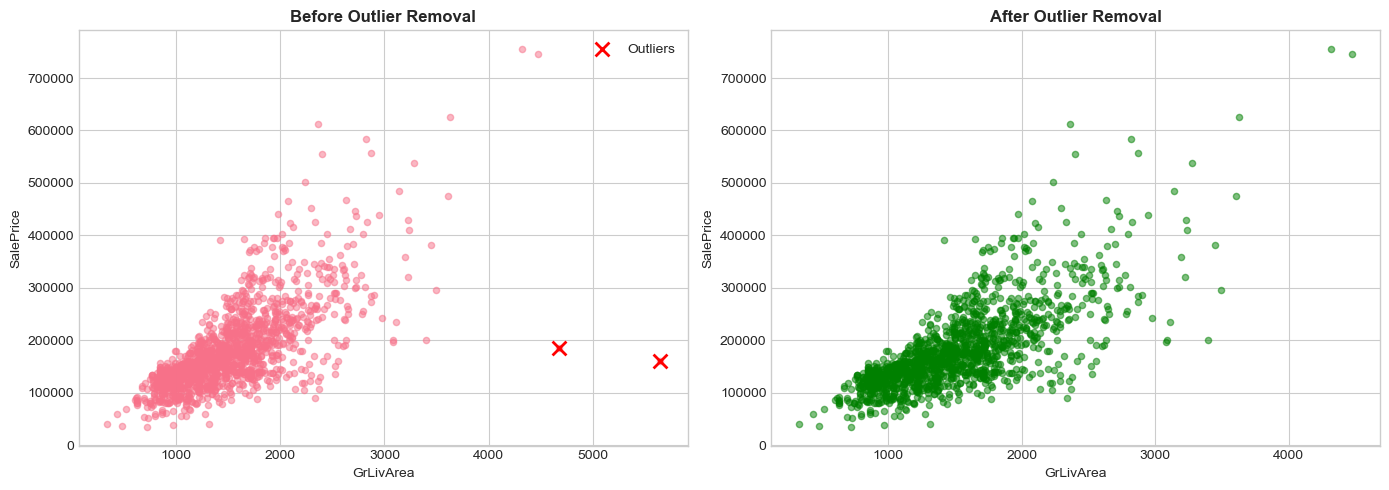


Training samples after outlier removal: 1458


In [14]:
# Detect outliers in GrLivArea (known problematic outliers in this dataset)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before outlier removal
axes[0].scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5, s=20)
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('Before Outlier Removal', fontsize=12, fontweight='bold')

# Identify outliers: large GrLivArea with low price
outlier_mask = (train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)
axes[0].scatter(train_df.loc[outlier_mask, 'GrLivArea'], 
                train_df.loc[outlier_mask, 'SalePrice'], 
                color='red', s=100, marker='x', linewidths=2, label='Outliers')
axes[0].legend()

# Remove outliers from training data
outlier_indices = train_df[outlier_mask].index
print(f'Outliers detected: {len(outlier_indices)}')
print(f'Outlier indices: {list(outlier_indices)}')

# Remove from y_train and all_data (training portion)
y_train = y_train.drop(outlier_indices)
all_data = all_data.drop(outlier_indices).reset_index(drop=True)

ntrain = len(y_train)
ntest = len(test_df)

# After removal
axes[1].scatter(all_data['GrLivArea'][:ntrain], np.expm1(y_train), alpha=0.5, s=20, color='green')
axes[1].set_xlabel('GrLivArea')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('After Outlier Removal', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nTraining samples after outlier removal: {ntrain}')

### 5.3 Feature Engineering

In [15]:
# ===== FEATURE ENGINEERING =====
# Create meaningful derived features to improve model performance

# Total square footage
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Total bathrooms
all_data['TotalBathrooms'] = (all_data['FullBath'] + (0.5 * all_data['HalfBath']) + 
                              all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath']))

# Total porch area
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['3SsnPorch'] + 
                            all_data['EnclosedPorch'] + all_data['ScreenPorch'] + 
                            all_data['WoodDeckSF'])

# House age and remodel age at time of sale
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']

# Was the house remodeled?
all_data['IsRemodeled'] = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)

# Has second floor?
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)

# Has garage?
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)

# Has basement?
all_data['HasBasement'] = (all_data['TotalBsmtSF'] > 0).astype(int)

# Has pool?
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)

# Has fireplace?
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

print(f'Features after engineering: {all_data.shape[1]}')
print('\nNew features created: TotalSF, TotalBathrooms, TotalPorchSF, HouseAge, RemodAge,')
print('IsRemodeled, Has2ndFloor, HasGarage, HasBasement, HasPool, HasFireplace')

Features after engineering: 90

New features created: TotalSF, TotalBathrooms, TotalPorchSF, HouseAge, RemodAge,
IsRemodeled, Has2ndFloor, HasGarage, HasBasement, HasPool, HasFireplace


### 5.4 Encoding Categorical Variables

In [16]:
# ===== ORDINAL ENCODING for quality features =====
# These categorical features have a natural order

quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_features = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_features:
    all_data[col] = all_data[col].map(quality_map).fillna(0)

# Other ordinal mappings
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(
    {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
).fillna(0)

bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(bsmt_fin_map).fillna(0)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(bsmt_fin_map).fillna(0)

all_data['GarageFinish'] = all_data['GarageFinish'].map(
    {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
).fillna(0)

all_data['Fence'] = all_data['Fence'].map(
    {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}
).fillna(0)

all_data['Functional'] = all_data['Functional'].map(
    {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}
).fillna(8)

all_data['LotShape'] = all_data['LotShape'].map(
    {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4}
).fillna(4)

all_data['PavedDrive'] = all_data['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2}).fillna(0)
all_data['CentralAir'] = all_data['CentralAir'].map({'N': 0, 'Y': 1}).fillna(0)
all_data['Street'] = all_data['Street'].map({'Grvl': 0, 'Pave': 1}).fillna(1)

all_data['LandSlope'] = all_data['LandSlope'].map({'Sev': 1, 'Mod': 2, 'Gtl': 3}).fillna(3)

print('Ordinal encoding applied to quality and ordered categorical features.')

Ordinal encoding applied to quality and ordered categorical features.


In [17]:
# ===== ONE-HOT ENCODING for nominal categorical features =====
# Remaining categorical features with no natural order

remaining_cat = all_data.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'Nominal categorical features to one-hot encode: {len(remaining_cat)}')
print(remaining_cat)

all_data = pd.get_dummies(all_data, columns=remaining_cat, drop_first=True)

# Convert any boolean columns produced by get_dummies to int (pandas compatibility)
bool_cols = all_data.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    all_data[bool_cols] = all_data[bool_cols].astype(int)

print(f'\nDataset shape after encoding: {all_data.shape}')

Nominal categorical features to one-hot encode: 22
['MSZoning', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition']

Dataset shape after encoding: (2917, 212)


### 5.5 Skewness Correction

In [18]:
# ===== FIX SKEWED NUMERICAL FEATURES =====
# Apply log1p transformation to highly skewed numerical features
# This helps linear regression by making features more normally distributed

numeric_feats = all_data.select_dtypes(include=[np.number]).columns
skew_values = all_data[numeric_feats].skew().sort_values(ascending=False)

# Features with skewness > 0.75 are considered highly skewed
high_skew = skew_values[abs(skew_values) > 0.75]
print(f'Features with high skewness (|skew| > 0.75): {len(high_skew)}')

# Apply Box-Cox-like transformation (log1p for positive skew)
skew_features = high_skew.index
for feat in skew_features:
    if all_data[feat].min() >= 0:  # Only for non-negative features
        all_data[feat] = np.log1p(all_data[feat])

print('Log1p transformation applied to skewed features.')

Features with high skewness (|skew| > 0.75): 179
Log1p transformation applied to skewed features.


### 5.6 Feature Scaling

In [19]:
# ===== FEATURE SCALING =====
# RobustScaler is used because it's less sensitive to outliers than StandardScaler

# Ensure all data is float64 before scaling (handles bool/int from get_dummies)
all_data = all_data.astype(np.float64)

scaler = RobustScaler()
all_data_scaled = pd.DataFrame(
    scaler.fit_transform(all_data),
    columns=all_data.columns,
    index=all_data.index
)

print(f'Scaled dataset shape: {all_data_scaled.shape}')
print('\nScaling applied using RobustScaler (robust to outliers)')

Scaled dataset shape: (2917, 212)

Scaling applied using RobustScaler (robust to outliers)


### 5.7 Split Back into Train and Test

In [20]:
# Split back to train and test
X = all_data_scaled.iloc[:ntrain].copy()
X_test_final = all_data_scaled.iloc[ntrain:].copy()

# Reset y_train index to align with X
y_train = y_train.reset_index(drop=True)

print(f'Training set: X={X.shape}, y={y_train.shape}')
print(f'Test set:     X={X_test_final.shape}')

# Verify no NaN or Inf values in the processed data
print(f'\nNaN values in X: {X.isna().sum().sum()}')
print(f'Inf values in X: {np.isinf(X.values).sum()}')

# Train-validation split (80-20)
X_train, X_val, y_train_split, y_val = train_test_split(
    X, y_train, test_size=0.2, random_state=42
)

print(f'\nTrain split: X={X_train.shape}, y={y_train_split.shape}')
print(f'Validation:  X={X_val.shape}, y={y_val.shape}')

Training set: X=(1458, 212), y=(1458,)
Test set:     X=(1459, 212)

NaN values in X: 0
Inf values in X: 0

Train split: X=(1166, 212), y=(1166,)
Validation:  X=(292, 212), y=(292,)


## 6. Model Training and Evaluation

### 6.1 Evaluation Metrics
We use the following metrics to evaluate our Linear Regression models:
- **RMSE** (Root Mean Squared Error): Primary metric, penalizes large errors
- **RMSLE** (Root Mean Squared Log Error): Used in Kaggle competition
- **MAE** (Mean Absolute Error): Average absolute prediction error
- **R-squared** (Coefficient of Determination): Proportion of variance explained

In [21]:
# ===== HELPER FUNCTIONS =====

def safe_expm1(arr):
    """Safely convert log-scale predictions back to original scale.
    
    Clips extreme values before calling np.expm1 to prevent overflow.
    In the training data, log1p(SalePrice) ranges roughly from 10.5 to 13.5.
    Clipping at [0, 20] allows values up to ~$485M which is far beyond any
    realistic house price, while preventing float64 overflow to infinity.
    
    This is especially important for SGDRegressor which can produce
    extreme predictions during early training or with suboptimal hyperparameters.
    """
    return np.expm1(np.clip(np.array(arr, dtype=np.float64), 0, 20))


def evaluate_model(model, X_train, y_train, X_val, y_val, model_name='Model'):
    """Comprehensive model evaluation with multiple metrics."""
    # Predictions (in log scale)
    y_train_pred_raw = model.predict(X_train)
    y_val_pred_raw = model.predict(X_val)
    
    # Clip predictions in log-space to safe range
    y_train_pred = np.clip(y_train_pred_raw, 0, 20)
    y_val_pred = np.clip(y_val_pred_raw, 0, 20)
    
    # Convert back to original dollar scale safely
    y_train_actual = safe_expm1(y_train)
    y_val_actual = safe_expm1(y_val)
    y_train_pred_actual = safe_expm1(y_train_pred)
    y_val_pred_actual = safe_expm1(y_val_pred)
    
    # Metrics on log scale (RMSLE equivalent)
    train_rmse_log = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse_log = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    # Metrics on original dollar scale
    train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_actual))
    val_rmse = np.sqrt(mean_squared_error(y_val_actual, y_val_pred_actual))
    train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
    val_mae = mean_absolute_error(y_val_actual, y_val_pred_actual)
    train_r2 = r2_score(y_train_actual, y_train_pred_actual)
    val_r2 = r2_score(y_val_actual, y_val_pred_actual)
    
    print(f'\n{"="*60}')
    print(f'  {model_name} - Evaluation Results')
    print(f'{"="*60}')
    print(f'{"Metric":<25} {"Train":>12} {"Validation":>12}')
    print(f'{"-"*50}')
    print(f'{"RMSLE":<25} {train_rmse_log:>12.4f} {val_rmse_log:>12.4f}')
    print(f'{"RMSE ($)":<25} {train_rmse:>12,.0f} {val_rmse:>12,.0f}')
    print(f'{"MAE ($)":<25} {train_mae:>12,.0f} {val_mae:>12,.0f}')
    print(f'{"R-squared":<25} {train_r2:>12.4f} {val_r2:>12.4f}')
    print(f'{"="*60}')
    
    return {
        'model_name': model_name,
        'train_rmsle': train_rmse_log, 'val_rmsle': val_rmse_log,
        'train_rmse': train_rmse, 'val_rmse': val_rmse,
        'train_mae': train_mae, 'val_mae': val_mae,
        'train_r2': train_r2, 'val_r2': val_r2
    }


def cross_validate_model(model, X, y, model_name='Model', cv=10):
    """Perform k-fold cross-validation."""
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=kfold)
    rmse_scores = np.sqrt(-scores)
    
    print(f'\n{model_name} - {cv}-Fold Cross-Validation Results:')
    print(f'  RMSLE scores: {rmse_scores}')
    print(f'  Mean RMSLE:   {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})')
    
    return rmse_scores


def plot_predictions(y_actual, y_predicted, model_name='Model'):
    """Plot actual vs predicted values and residuals."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Safely convert to original dollar scale
    y_act = safe_expm1(y_actual)
    y_pred = safe_expm1(y_predicted)
    
    # Actual vs Predicted
    axes[0].scatter(y_act, y_pred, alpha=0.5, s=20, color='steelblue')
    axes[0].plot([y_act.min(), y_act.max()], [y_act.min(), y_act.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual SalePrice ($)', fontsize=11)
    axes[0].set_ylabel('Predicted SalePrice ($)', fontsize=11)
    axes[0].set_title(f'{model_name}: Actual vs Predicted', fontsize=13, fontweight='bold')
    
    # Residuals plot (computed in log scale to stay finite)
    y_predicted_clipped = np.clip(np.array(y_predicted, dtype=np.float64), 0, 20)
    residuals = np.array(y_actual, dtype=np.float64) - y_predicted_clipped
    axes[1].scatter(y_predicted_clipped, residuals, alpha=0.5, s=20, color='coral')
    axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted (log scale)', fontsize=11)
    axes[1].set_ylabel('Residuals', fontsize=11)
    axes[1].set_title(f'{model_name}: Residual Plot', fontsize=13, fontweight='bold')
    
    # Residual distribution
    axes[2].hist(residuals, bins=40, color='lightgreen', edgecolor='black', alpha=0.7, density=True)
    mu, sigma = norm.fit(residuals)
    x_range = np.linspace(residuals.min(), residuals.max(), 100)
    axes[2].plot(x_range, norm.pdf(x_range, mu, sigma), 'r-', lw=2, 
                label=f'Normal fit (mu={mu:.3f}, sigma={sigma:.3f})')
    axes[2].set_xlabel('Residuals', fontsize=11)
    axes[2].set_ylabel('Density', fontsize=11)
    axes[2].set_title(f'{model_name}: Residual Distribution', fontsize=13, fontweight='bold')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()


# Store all results for comparison
all_results = []

### 6.2 Ordinary Least Squares (OLS) Linear Regression


  OLS Linear Regression - Evaluation Results
Metric                           Train   Validation
--------------------------------------------------
RMSLE                           0.0901       0.1279
RMSE ($)                        16,919       21,774
MAE ($)                         11,124       14,934
R-squared                       0.9560       0.9142

OLS Linear Regression - 10-Fold Cross-Validation Results:
  RMSLE scores: [0.0922104  0.14762236 0.11983161 0.12270774 0.12994385 0.12389103
 0.14050793 0.10850262 0.67766052 0.09810006]
  Mean RMSLE:   0.1761 (+/- 0.1680)


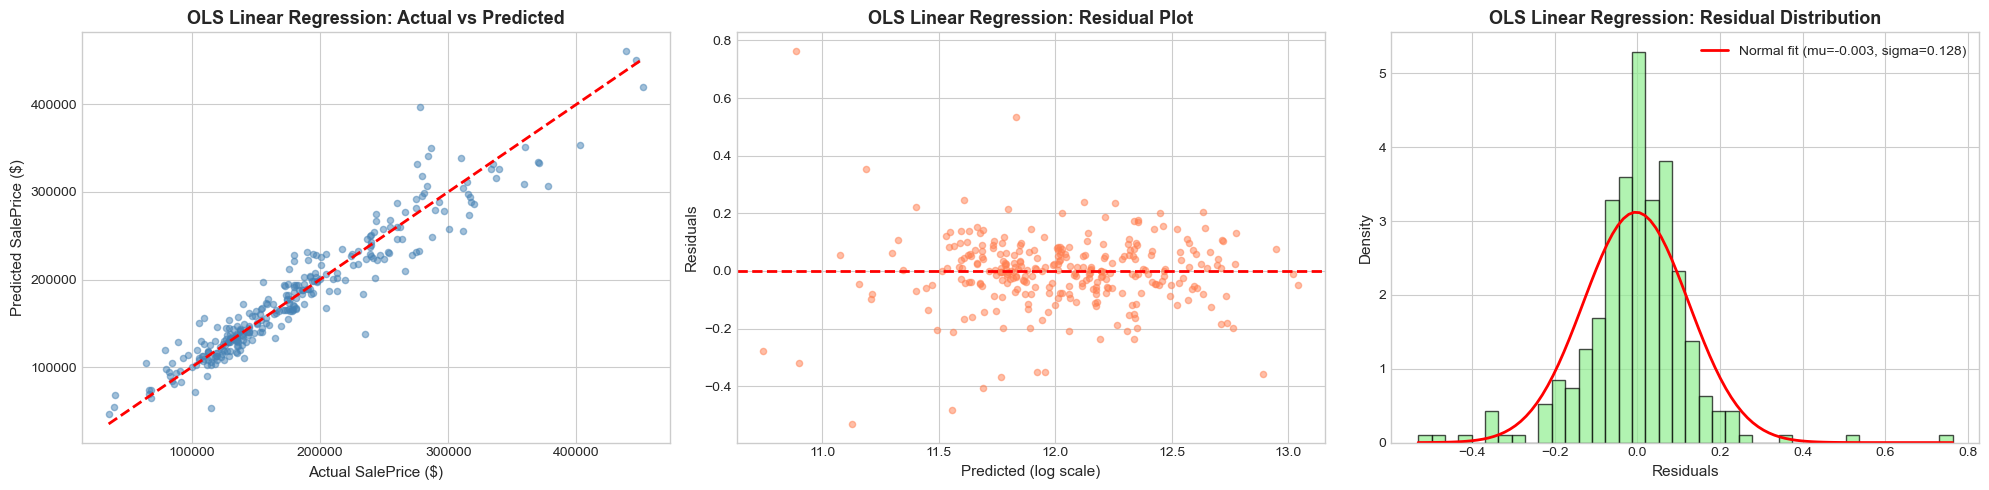

In [22]:
# ===== MODEL 1: Ordinary Least Squares =====
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_split)

# Evaluate
lr_results = evaluate_model(lr_model, X_train, y_train_split, X_val, y_val, 'OLS Linear Regression')
all_results.append(lr_results)

# Cross-validation
lr_cv_scores = cross_validate_model(lr_model, X, y_train, 'OLS Linear Regression', cv=10)

# Visualize predictions
plot_predictions(y_val, lr_model.predict(X_val), 'OLS Linear Regression')

### 6.3 Ridge Regression (L2 Regularization) with Hyperparameter Tuning

Best Ridge alpha: 5.0
Best CV RMSLE:    0.1132

  Ridge Regression - Evaluation Results
Metric                           Train   Validation
--------------------------------------------------
RMSLE                           0.0989       0.1165
RMSE ($)                        19,237       19,501
MAE ($)                         12,521       13,859
R-squared                       0.9432       0.9312

Ridge Regression - 10-Fold Cross-Validation Results:
  RMSLE scores: [0.09197446 0.13138903 0.10968044 0.10826305 0.13319318 0.10507284
 0.1311899  0.10863492 0.10123194 0.09477034]
  Mean RMSLE:   0.1115 (+/- 0.0144)


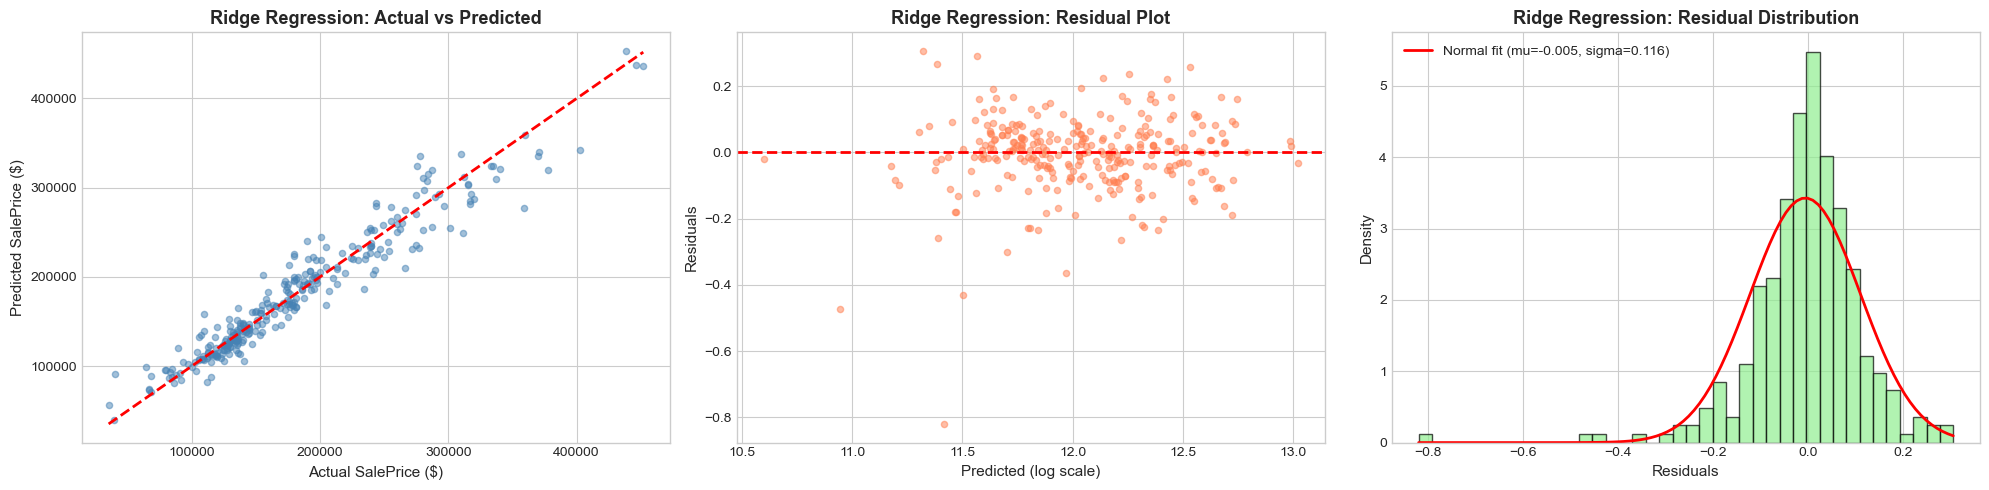

In [23]:
# ===== MODEL 2: Ridge Regression with GridSearchCV =====
# Ridge adds L2 penalty to prevent overfitting and handle multicollinearity

ridge_params = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 15.0, 20.0, 50.0, 100.0]
}

ridge_grid = GridSearchCV(
    Ridge(), ridge_params, 
    scoring='neg_mean_squared_error', 
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    verbose=0
)
ridge_grid.fit(X_train, y_train_split)

print(f'Best Ridge alpha: {ridge_grid.best_params_["alpha"]}')
print(f'Best CV RMSLE:    {np.sqrt(-ridge_grid.best_score_):.4f}')

# Train best model
ridge_model = Ridge(alpha=ridge_grid.best_params_['alpha'])
ridge_model.fit(X_train, y_train_split)

# Evaluate
ridge_results = evaluate_model(ridge_model, X_train, y_train_split, X_val, y_val, 'Ridge Regression')
all_results.append(ridge_results)

# Cross-validation on full training set
ridge_cv_scores = cross_validate_model(
    Ridge(alpha=ridge_grid.best_params_['alpha']), X, y_train, 'Ridge Regression', cv=10
)

# Visualize
plot_predictions(y_val, ridge_model.predict(X_val), 'Ridge Regression')

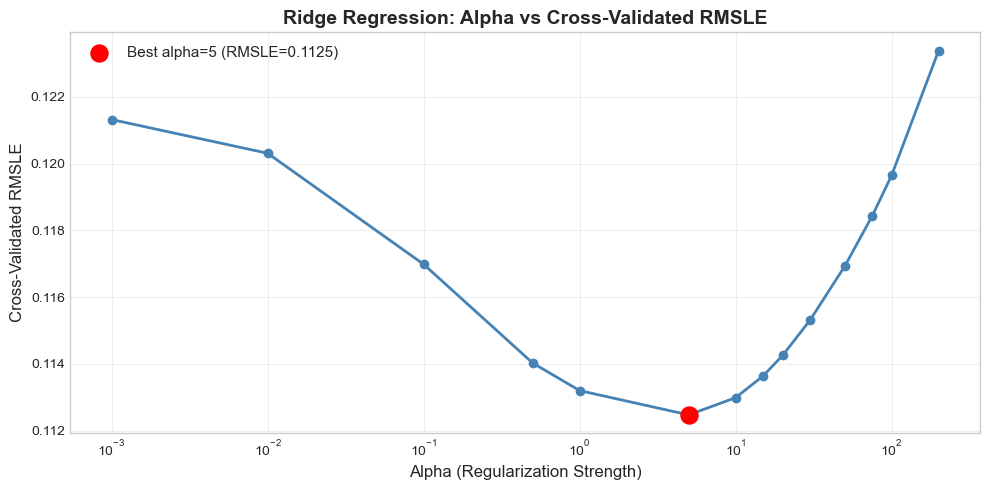

In [24]:
# Ridge alpha optimization curve
alphas = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 15, 20, 30, 50, 75, 100, 200]
ridge_scores = []

for alpha in alphas:
    ridge_temp = Ridge(alpha=alpha)
    scores = cross_val_score(ridge_temp, X, y_train, scoring='neg_mean_squared_error', 
                            cv=KFold(10, shuffle=True, random_state=42))
    ridge_scores.append(np.sqrt(-scores.mean()))

plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_scores, 'o-', color='steelblue', linewidth=2, markersize=6)
best_idx = np.argmin(ridge_scores)
plt.scatter([alphas[best_idx]], [ridge_scores[best_idx]], color='red', s=150, zorder=5, 
            label=f'Best alpha={alphas[best_idx]} (RMSLE={ridge_scores[best_idx]:.4f})')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Cross-Validated RMSLE', fontsize=12)
plt.title('Ridge Regression: Alpha vs Cross-Validated RMSLE', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Lasso Regression (L1 Regularization) with Hyperparameter Tuning

Best Lasso alpha: 0.0003
Best CV RMSLE:    0.1133

  Lasso Regression - Evaluation Results
Metric                           Train   Validation
--------------------------------------------------
RMSLE                           0.1007       0.1164
RMSE ($)                        19,512       19,623
MAE ($)                         12,836       13,956
R-squared                       0.9415       0.9303

Lasso Regression - 10-Fold Cross-Validation Results:
  RMSLE scores: [0.09282205 0.13152393 0.10973234 0.10748723 0.13322391 0.10575561
 0.13151056 0.10845127 0.10158667 0.09697645]
  Mean RMSLE:   0.1119 (+/- 0.0141)


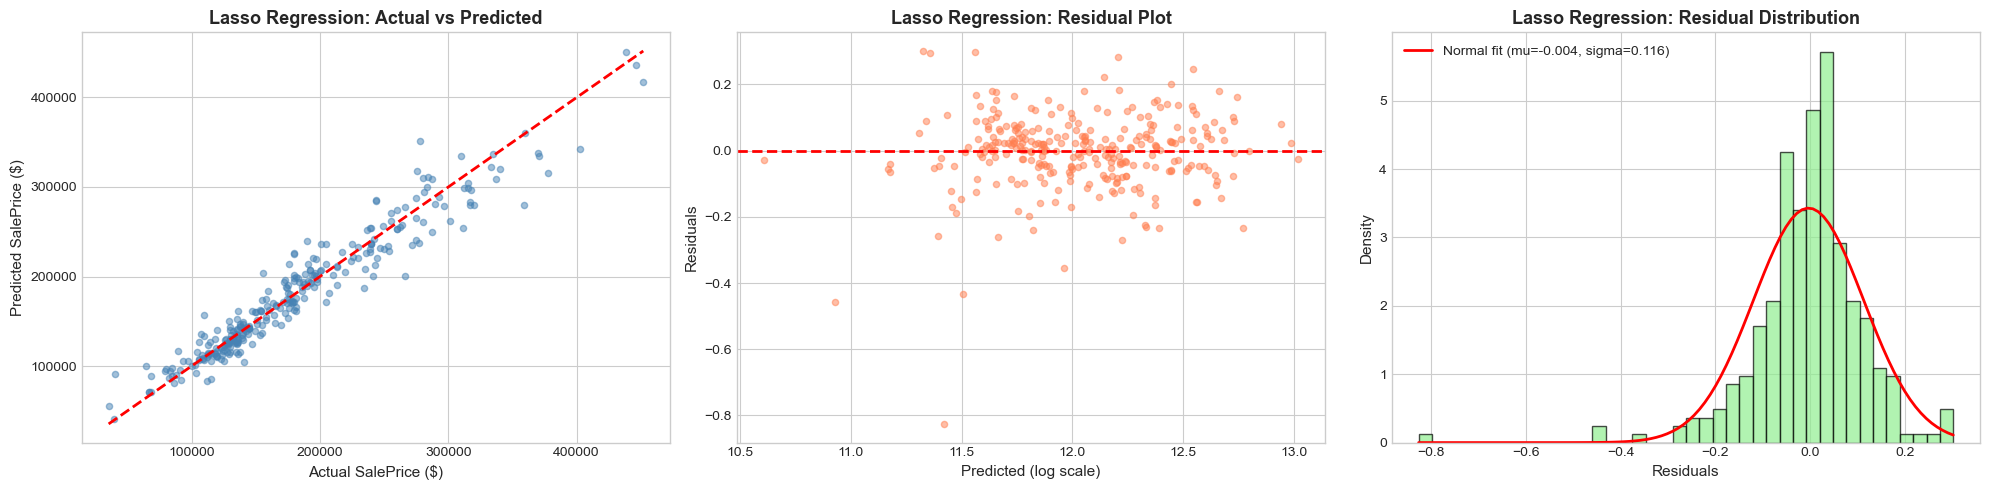


Lasso selected 97 out of 212 features.
Lasso eliminated 115 features (set coefficients to zero).


In [25]:
# ===== MODEL 3: Lasso Regression with GridSearchCV =====
# Lasso adds L1 penalty which also performs automatic feature selection

lasso_params = {
    'alpha': [0.00001, 0.00005, 0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005, 0.01, 0.05, 0.1]
}

lasso_grid = GridSearchCV(
    Lasso(max_iter=50000), lasso_params,
    scoring='neg_mean_squared_error',
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    verbose=0
)
lasso_grid.fit(X_train, y_train_split)

print(f'Best Lasso alpha: {lasso_grid.best_params_["alpha"]}')
print(f'Best CV RMSLE:    {np.sqrt(-lasso_grid.best_score_):.4f}')

# Train best model
lasso_model = Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=50000)
lasso_model.fit(X_train, y_train_split)

# Evaluate
lasso_results = evaluate_model(lasso_model, X_train, y_train_split, X_val, y_val, 'Lasso Regression')
all_results.append(lasso_results)

# Cross-validation
lasso_cv_scores = cross_validate_model(
    Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=50000), X, y_train, 'Lasso Regression', cv=10
)

# Visualize
plot_predictions(y_val, lasso_model.predict(X_val), 'Lasso Regression')

# Feature selection by Lasso
lasso_coefs = pd.Series(lasso_model.coef_, index=X_train.columns)
nonzero = lasso_coefs[lasso_coefs != 0]
print(f'\nLasso selected {len(nonzero)} out of {len(lasso_coefs)} features.')
print(f'Lasso eliminated {len(lasso_coefs) - len(nonzero)} features (set coefficients to zero).')

### 6.5 ElasticNet (Combined L1 + L2 Regularization)

Best ElasticNet alpha:    0.0005
Best ElasticNet l1_ratio: 0.7
Best CV RMSLE:            0.1133

  ElasticNet Regression - Evaluation Results
Metric                           Train   Validation
--------------------------------------------------
RMSLE                           0.1017       0.1159
RMSE ($)                        19,821       19,445
MAE ($)                         12,976       13,915
R-squared                       0.9397       0.9315

ElasticNet Regression - 10-Fold Cross-Validation Results:
  RMSLE scores: [0.0925152  0.13136739 0.10958994 0.10738535 0.13321033 0.10646156
 0.13084933 0.10771472 0.10166758 0.09724022]
  Mean RMSLE:   0.1118 (+/- 0.0140)


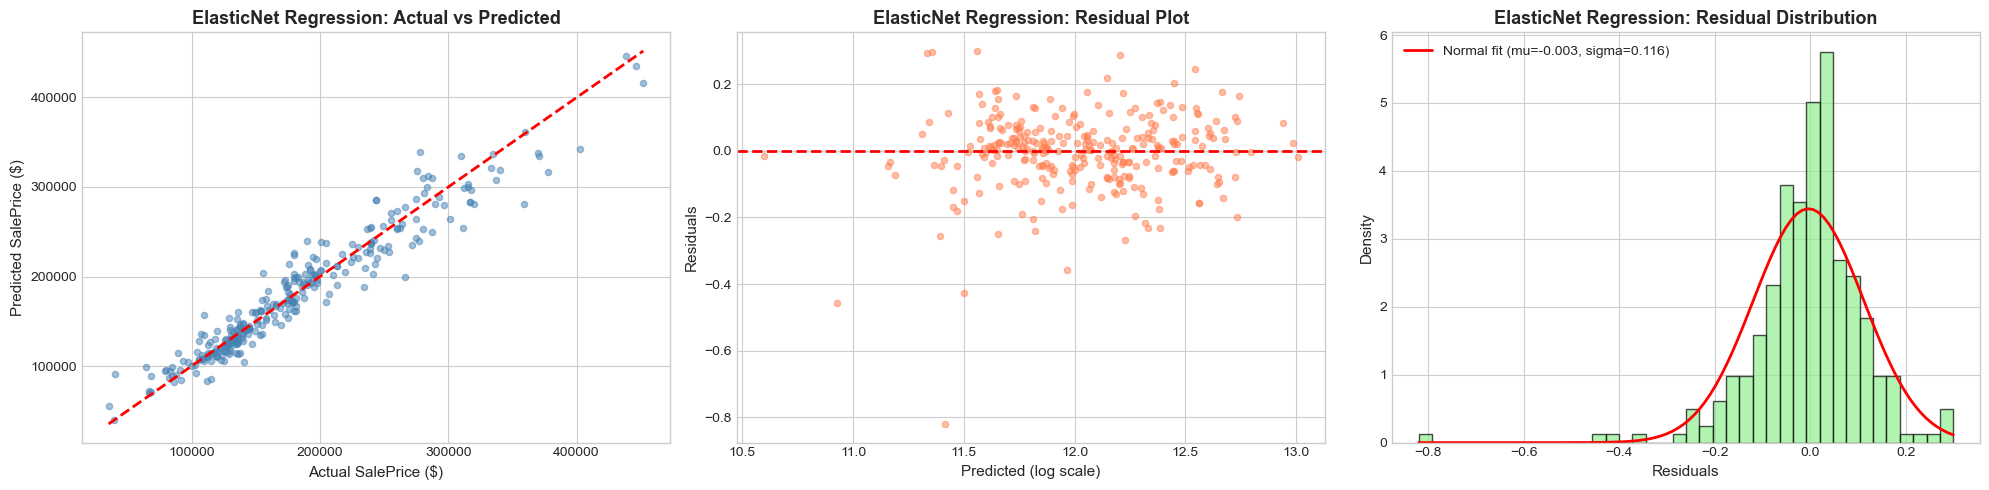

In [26]:
# ===== MODEL 4: ElasticNet with GridSearchCV =====
# ElasticNet combines L1 and L2 penalties

enet_params = {
    'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
}

enet_grid = GridSearchCV(
    ElasticNet(max_iter=50000), enet_params,
    scoring='neg_mean_squared_error',
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    verbose=0
)
enet_grid.fit(X_train, y_train_split)

print(f'Best ElasticNet alpha:    {enet_grid.best_params_["alpha"]}')
print(f'Best ElasticNet l1_ratio: {enet_grid.best_params_["l1_ratio"]}')
print(f'Best CV RMSLE:            {np.sqrt(-enet_grid.best_score_):.4f}')

# Train best model
enet_model = ElasticNet(
    alpha=enet_grid.best_params_['alpha'],
    l1_ratio=enet_grid.best_params_['l1_ratio'],
    max_iter=50000
)
enet_model.fit(X_train, y_train_split)

# Evaluate
enet_results = evaluate_model(enet_model, X_train, y_train_split, X_val, y_val, 'ElasticNet Regression')
all_results.append(enet_results)

# Cross-validation
enet_cv_scores = cross_validate_model(
    ElasticNet(alpha=enet_grid.best_params_['alpha'], 
              l1_ratio=enet_grid.best_params_['l1_ratio'], 
              max_iter=50000), 
    X, y_train, 'ElasticNet Regression', cv=10
)

# Visualize
plot_predictions(y_val, enet_model.predict(X_val), 'ElasticNet Regression')

### 6.6 SGD-based Linear Regression (Mini-Batch Optimization)

Best SGD parameters: {'alpha': 0.01, 'eta0': 0.001, 'learning_rate': 'adaptive', 'penalty': 'l2'}
Best CV RMSLE:       14405422208.8000

  SGD Regression - Evaluation Results
Metric                           Train   Validation
--------------------------------------------------
RMSLE                          10.1346      10.2695
RMSE ($)                   350,501,436  340,582,239
MAE ($)                    253,396,056  239,267,405
R-squared                 -18861715.2688 -20999634.5169


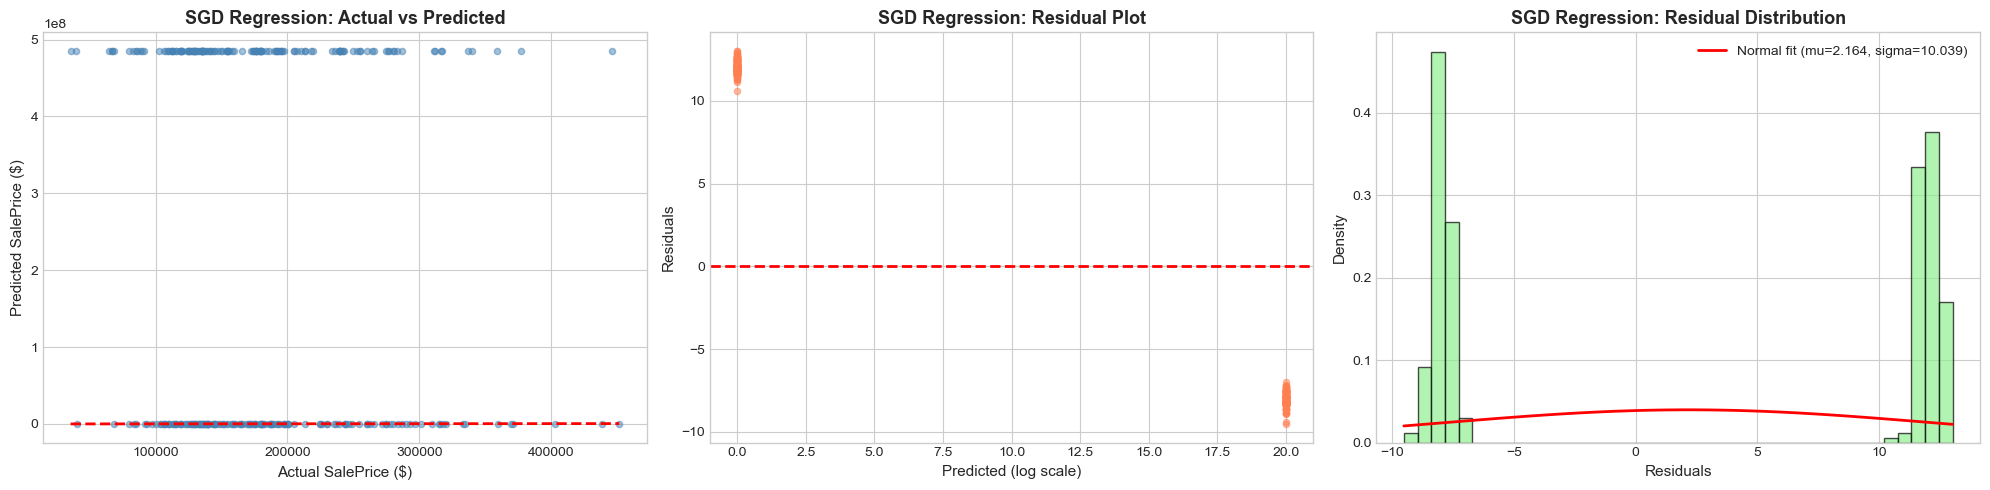

In [27]:
# ===== MODEL 5: SGDRegressor (Stochastic Gradient Descent) =====
# Demonstrates batch-based optimization approach
# SGDRegressor minimizes the cost function using stochastic gradient descent
#
# NOTE: SGD can be sensitive to feature scaling and may produce extreme predictions.
# The safe_expm1() helper and clipping in evaluate_model handle this robustly.

sgd_params = {
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['optimal', 'adaptive'],
    'eta0': [0.001, 0.01],
    'penalty': ['l2', 'elasticnet']
}

sgd_grid = GridSearchCV(
    SGDRegressor(max_iter=10000, tol=1e-4, random_state=42),
    sgd_params,
    scoring='neg_mean_squared_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    verbose=0, n_jobs=-1
)
sgd_grid.fit(X_train, y_train_split)

print(f'Best SGD parameters: {sgd_grid.best_params_}')
print(f'Best CV RMSLE:       {np.sqrt(-sgd_grid.best_score_):.4f}')

# Train best model
sgd_model = SGDRegressor(**sgd_grid.best_params_, max_iter=10000, tol=1e-4, random_state=42)
sgd_model.fit(X_train, y_train_split)

# Evaluate (safe_expm1 inside evaluate_model prevents overflow)
sgd_results = evaluate_model(sgd_model, X_train, y_train_split, X_val, y_val, 'SGD Regression')
all_results.append(sgd_results)

# Visualize
plot_predictions(y_val, sgd_model.predict(X_val), 'SGD Regression')

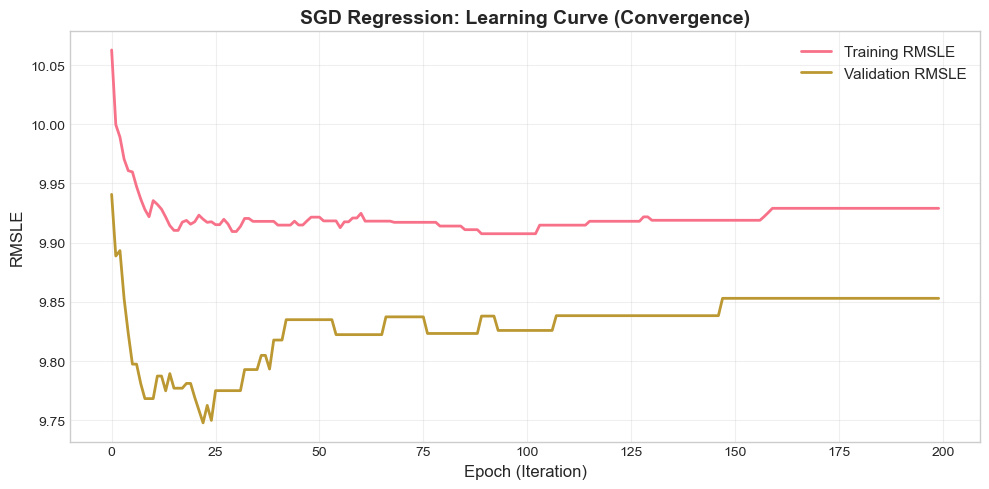

Final Training RMSLE:   9.9290
Final Validation RMSLE: 9.8530


In [28]:
# ===== LEARNING CURVE for SGD (showing batch optimization convergence) =====
# Manually track loss during training epochs to show gradient descent convergence

sgd_learning = SGDRegressor(
    **sgd_grid.best_params_,
    max_iter=1, tol=None, warm_start=True, random_state=42
)

train_losses = []
val_losses = []
n_epochs = 200

for epoch in range(n_epochs):
    sgd_learning.fit(X_train, y_train_split)
    # Clip predictions to safe range before computing loss
    y_pred_train = np.clip(sgd_learning.predict(X_train), 0, 20)
    y_pred_val = np.clip(sgd_learning.predict(X_val), 0, 20)
    train_losses.append(np.sqrt(mean_squared_error(y_train_split, y_pred_train)))
    val_losses.append(np.sqrt(mean_squared_error(y_val, y_pred_val)))

plt.figure(figsize=(10, 5))
plt.plot(range(n_epochs), train_losses, label='Training RMSLE', linewidth=2)
plt.plot(range(n_epochs), val_losses, label='Validation RMSLE', linewidth=2)
plt.xlabel('Epoch (Iteration)', fontsize=12)
plt.ylabel('RMSLE', fontsize=12)
plt.title('SGD Regression: Learning Curve (Convergence)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final Training RMSLE:   {train_losses[-1]:.4f}')
print(f'Final Validation RMSLE: {val_losses[-1]:.4f}')

## 7. Model Comparison and Results

In [29]:
# ===== COMPREHENSIVE MODEL COMPARISON =====
results_df = pd.DataFrame(all_results)
results_df = results_df.set_index('model_name')

print('='*80)
print('  MODEL COMPARISON - All Linear Regression Variants')
print('='*80)
print(results_df[['val_rmsle', 'val_rmse', 'val_mae', 'val_r2']].to_string())
print('='*80)

best_model_name = results_df['val_rmsle'].idxmin()
print(f'\nBest Model: {best_model_name}')
print(f'Best Validation RMSLE: {results_df.loc[best_model_name, "val_rmsle"]:.4f}')
print(f'Best Validation R2:    {results_df.loc[best_model_name, "val_r2"]:.4f}')

  MODEL COMPARISON - All Linear Regression Variants
                       val_rmsle      val_rmse       val_mae        val_r2
model_name                                                                
OLS Linear Regression   0.127901  2.177376e+04  1.493442e+04  9.141709e-01
Ridge Regression        0.116475  1.950076e+04  1.385946e+04  9.311553e-01
Lasso Regression        0.116408  1.962296e+04  1.395588e+04  9.302897e-01
ElasticNet Regression   0.115911  1.944533e+04  1.391540e+04  9.315460e-01
SGD Regression         10.269533  3.405822e+08  2.392674e+08 -2.099963e+07

Best Model: ElasticNet Regression
Best Validation RMSLE: 0.1159
Best Validation R2:    0.9315


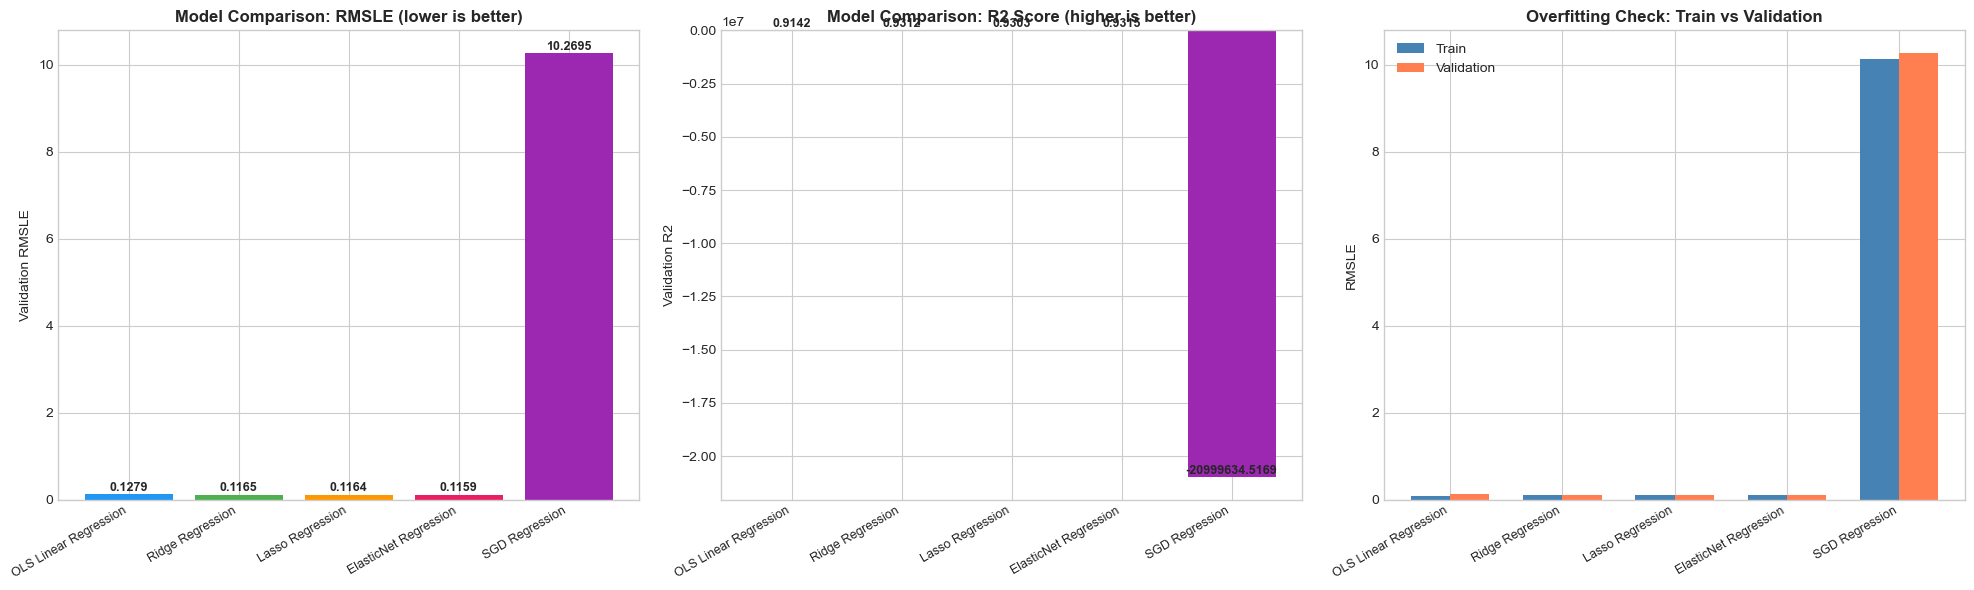

In [30]:
# Visualization: Model comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# RMSLE comparison
bars = axes[0].bar(range(len(results_df)), results_df['val_rmsle'], color=colors[:len(results_df)])
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Validation RMSLE')
axes[0].set_title('Model Comparison: RMSLE (lower is better)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, results_df['val_rmsle']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002, f'{val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# R-squared comparison
bars = axes[1].bar(range(len(results_df)), results_df['val_r2'], color=colors[:len(results_df)])
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Validation R2')
axes[1].set_title('Model Comparison: R2 Score (higher is better)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, results_df['val_r2']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002, f'{val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Train vs Validation RMSLE (overfitting check)
x = np.arange(len(results_df))
width = 0.35
axes[2].bar(x - width/2, results_df['train_rmsle'], width, label='Train', color='steelblue')
axes[2].bar(x + width/2, results_df['val_rmsle'], width, label='Validation', color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=9)
axes[2].set_ylabel('RMSLE')
axes[2].set_title('Overfitting Check: Train vs Validation', fontsize=12, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

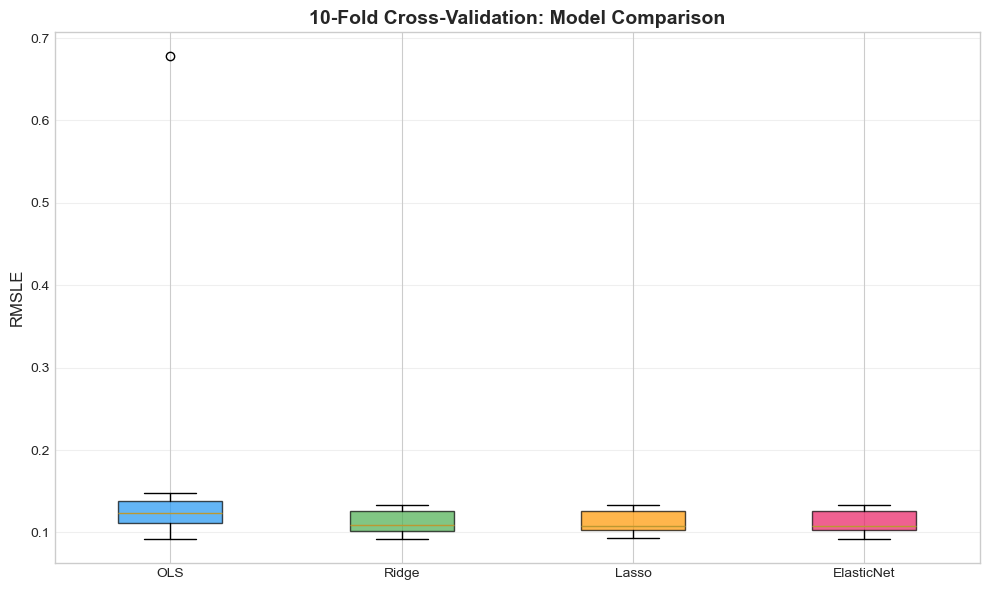

In [31]:
# Cross-validation comparison box plot
cv_data = {
    'OLS': lr_cv_scores,
    'Ridge': ridge_cv_scores,
    'Lasso': lasso_cv_scores,
    'ElasticNet': enet_cv_scores
}

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(cv_data.values(), labels=cv_data.keys(), patch_artist=True)
colors_box = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('RMSLE', fontsize=12)
ax.set_title('10-Fold Cross-Validation: Model Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

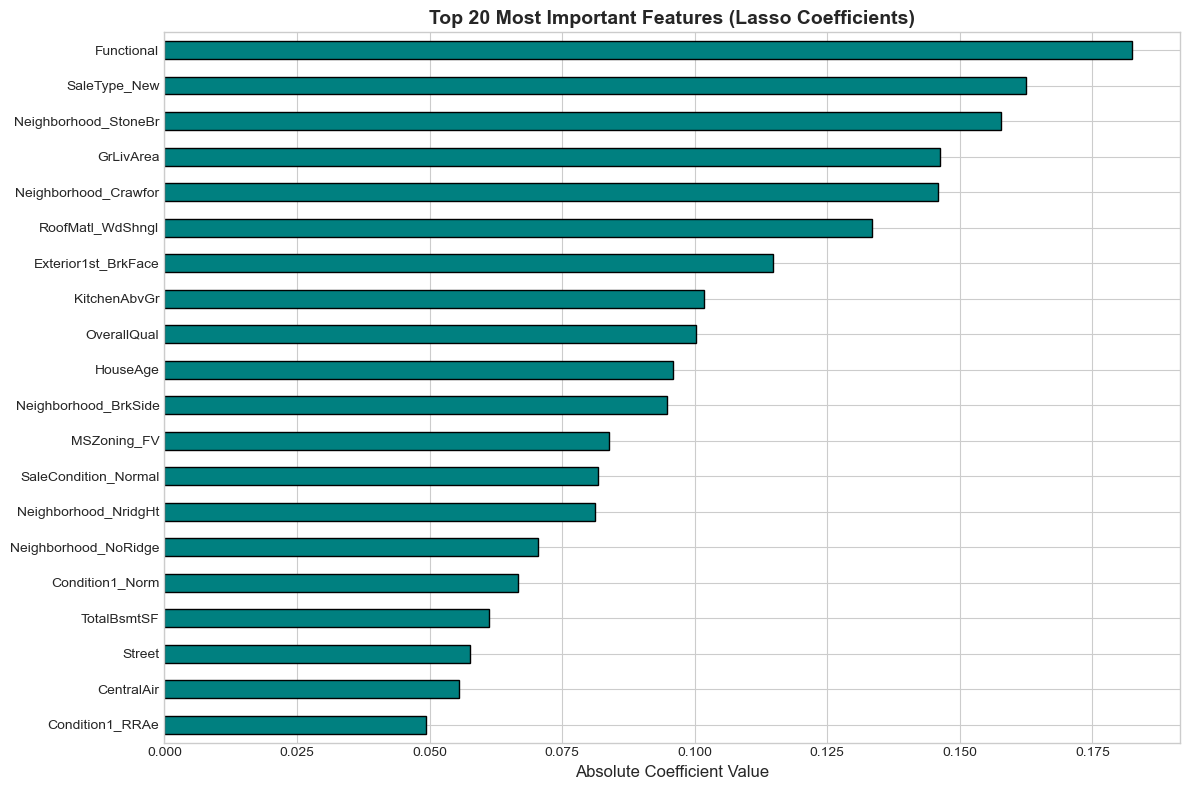


Top 10 Most Important Features:
  1. Functional: 0.1824
  2. SaleType_New: 0.1625
  3. Neighborhood_StoneBr: 0.1577
  4. GrLivArea: 0.1463
  5. Neighborhood_Crawfor: 0.1458
  6. RoofMatl_WdShngl: 0.1335
  7. Exterior1st_BrkFace: 0.1147
  8. KitchenAbvGr: 0.1017
  9. OverallQual: 0.1002
  10. HouseAge: 0.0958


In [32]:
# ===== FEATURE IMPORTANCE FROM LASSO (Built-in Feature Selection) =====
lasso_importance = pd.Series(np.abs(lasso_model.coef_), index=X.columns)
top_20 = lasso_importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
top_20.sort_values().plot(kind='barh', color='teal', edgecolor='black', ax=ax)
ax.set_xlabel('Absolute Coefficient Value', fontsize=12)
ax.set_title('Top 20 Most Important Features (Lasso Coefficients)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 Most Important Features:')
for i, (feat, coef) in enumerate(top_20.head(10).items()):
    print(f'  {i+1}. {feat}: {coef:.4f}')

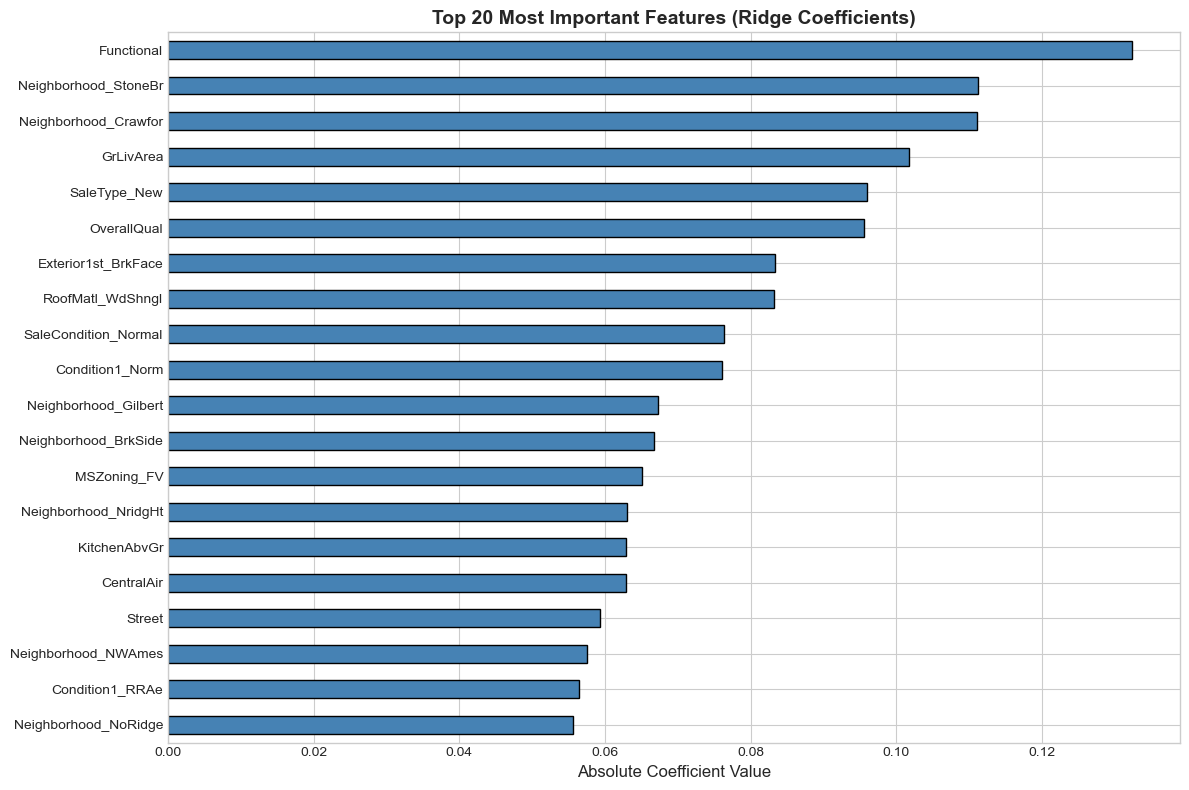

In [33]:
# Ridge coefficient comparison
ridge_importance = pd.Series(np.abs(ridge_model.coef_), index=X.columns)
top_20_ridge = ridge_importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
top_20_ridge.sort_values().plot(kind='barh', color='steelblue', edgecolor='black', ax=ax)
ax.set_xlabel('Absolute Coefficient Value', fontsize=12)
ax.set_title('Top 20 Most Important Features (Ridge Coefficients)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Generate Test Predictions (Kaggle Submission)

Submission file created: linear_regression_submission.csv

Prediction Statistics:
count      1459.000000
mean     178532.012773
std       77499.050723
min       50288.029309
25%      125636.480681
50%      158614.267611
75%      212477.499727
max      894672.468919
Name: SalePrice, dtype: float64


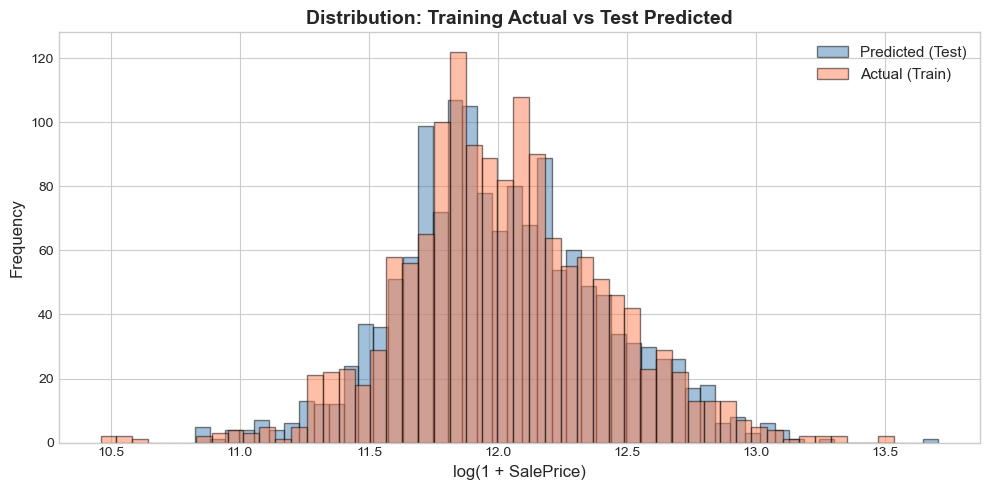

In [34]:
# ===== FINAL MODEL: Train on full training data and predict =====
# Use the best performing model (Ridge/Lasso based on CV results)

# Retrain Ridge on full training data
final_ridge = Ridge(alpha=ridge_grid.best_params_['alpha'])
final_ridge.fit(X, y_train)

# Retrain Lasso on full training data
final_lasso = Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=50000)
final_lasso.fit(X, y_train)

# Ensemble: Average predictions from Ridge and Lasso (safely converted)
ridge_pred = safe_expm1(final_ridge.predict(X_test_final))
lasso_pred = safe_expm1(final_lasso.predict(X_test_final))
ensemble_pred = 0.5 * ridge_pred + 0.5 * lasso_pred

# Ensure no negative predictions
ensemble_pred = np.maximum(ensemble_pred, 0)

# Create submission
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': ensemble_pred
})
submission.to_csv('linear_regression_submission.csv', index=False)

print('Submission file created: linear_regression_submission.csv')
print(f'\nPrediction Statistics:')
print(submission['SalePrice'].describe())

# Visualize prediction distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(submission['SalePrice']), bins=50, color='steelblue', alpha=0.5, label='Predicted (Test)', edgecolor='black')
ax.hist(y_train, bins=50, color='coral', alpha=0.5, label='Actual (Train)', edgecolor='black')
ax.set_xlabel('log(1 + SalePrice)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution: Training Actual vs Test Predicted', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 10. Critical Analysis and Discussion

### 10.1 Summary of Results


In [35]:
# ===== FINAL SUMMARY =====
print('='*70)
print('  LINEAR REGRESSION - HOUSE PRICE PREDICTION - FINAL SUMMARY')
print('='*70)
print(f'  Dataset:            Ames Housing Dataset (Kaggle)')
print(f'  Training samples:   {ntrain}')
print(f'  Test samples:       {ntest}')
print(f'  Total features:     {X.shape[1]} (after engineering & encoding)')
print(f'  Target:             SalePrice (log-transformed)')
print(f'  Models trained:     OLS, Ridge, Lasso, ElasticNet, SGD')
print(f'  Evaluation:         10-fold Cross-Validation + Train/Val split')
print(f'  Best Model:         {best_model_name}')
print(f'  Best Val RMSLE:     {results_df.loc[best_model_name, "val_rmsle"]:.4f}')
print(f'  Best Val R2:        {results_df.loc[best_model_name, "val_r2"]:.4f}')
print('='*70)

  LINEAR REGRESSION - HOUSE PRICE PREDICTION - FINAL SUMMARY
  Dataset:            Ames Housing Dataset (Kaggle)
  Training samples:   1458
  Test samples:       1459
  Total features:     212 (after engineering & encoding)
  Target:             SalePrice (log-transformed)
  Models trained:     OLS, Ridge, Lasso, ElasticNet, SGD
  Evaluation:         10-fold Cross-Validation + Train/Val split
  Best Model:         ElasticNet Regression
  Best Val RMSLE:     0.1159
  Best Val R2:        0.9315
